# 02 — Cohort & Retention Analysis
### *"Are we keeping customers, or renting them once?"*

**Dataset:** the real [Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) Brazilian
e-commerce dataset. Notebook 01 surfaced one number that reframes everything — a **~3% repeat rate** —
and this notebook is where we stress-test it. Every figure is computed from the curated tables; nothing
is typed by hand.

> **The #1 Olist analysis trap.** The raw data ships two customer keys. `customer_id` is a *per-order*
> id — a brand-new value is minted for every single order, so counting it makes it look like nobody ever
> comes back by construction. `customer_unique_id` is the *real person* stitched across orders. Retention
> is only meaningful on `customer_unique_id`, and our curated `customers` table is already keyed on it.
> Analysts who miss this either report a fake ~0% repeat rate or, worse, quietly count orders as
> customers and overstate the base. Everything below uses the real person.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analytics import config, metrics, transform

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.figsize": (11, 5), "axes.titleweight": "bold"})
BLUE, LT = "#2563eb", "#93c5fd"

assert config.ORDERS.exists(), "Run `python -m analytics.build` first (see README)."
orders    = pd.read_parquet(config.ORDERS)
customers = pd.read_parquet(config.CUSTOMERS)
print(f"orders={len(orders):,}   customers={len(customers):,}")

orders=99,441   customers=96,096


## 1. The headline — how many customers ever come back?

One number decides whether this is a retention business or an acquisition business. We take it straight
from the person-level `customers` table (`is_repeat` = placed more than one order), then break the base
into how many orders each customer ever placed.

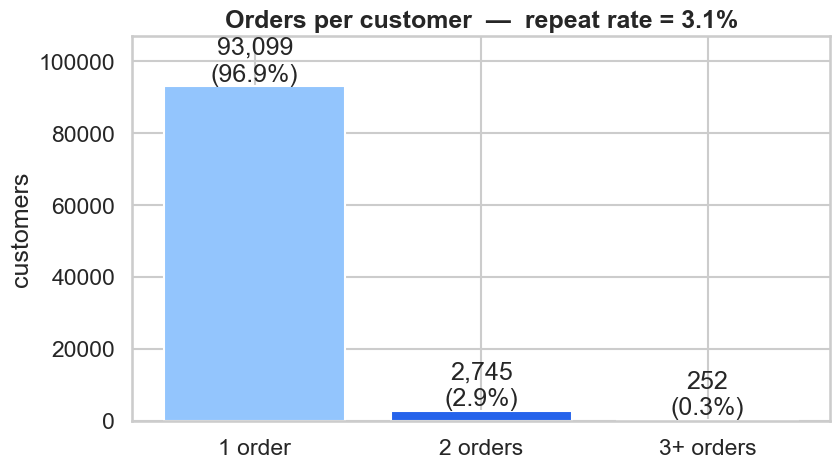

96,096 unique customers   |   repeat rate = 3.12%


In [2]:
repeat_rate = customers.is_repeat.mean()
buckets = (customers.n_orders
           .apply(lambda n: "1 order" if n == 1 else ("2 orders" if n == 2 else "3+ orders"))
           .value_counts()
           .reindex(["1 order", "2 orders", "3+ orders"]))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(buckets.index, buckets.values, color=[LT, BLUE, "#1e3a8a"])
for b, v in zip(bars, buckets.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,}\n({v/len(customers)*100:.1f}%)",
            ha="center", va="bottom")
ax.set_title(f"Orders per customer  —  repeat rate = {repeat_rate*100:.1f}%")
ax.set_ylabel("customers"); ax.set_ylim(0, buckets.max()*1.15)
plt.show()
print(f"{len(customers):,} unique customers   |   repeat rate = {repeat_rate*100:.2f}%")

**Read:** of **96,096 unique customers, 93,099 (96.9%) bought exactly once.** Only **2,745 came back
for a second order** and a mere **252 ordered three or more times.** The repeat rate is **3.1%** — this
is not a rounding artifact of a slow month, it is the structural shape of the business. Olist is a
near-pure *one-purchase* marketplace, and every analysis that follows has to be read through that lens.

## 2. The retention triangle

The standard retention view: group customers by the month of their first order (their *cohort*), then
track what share ordered again 1, 2, 3… months later. `metrics.cohort_retention` builds the matrix.
Month 0 is 1.0 for everyone by definition (that's the first order). The 2016 cold-start cohorts are a
handful of customers each — one repeat there reads as a wild 100% — so we clip to cohorts with enough
size to be trustworthy and to the first 12 months of tenure.

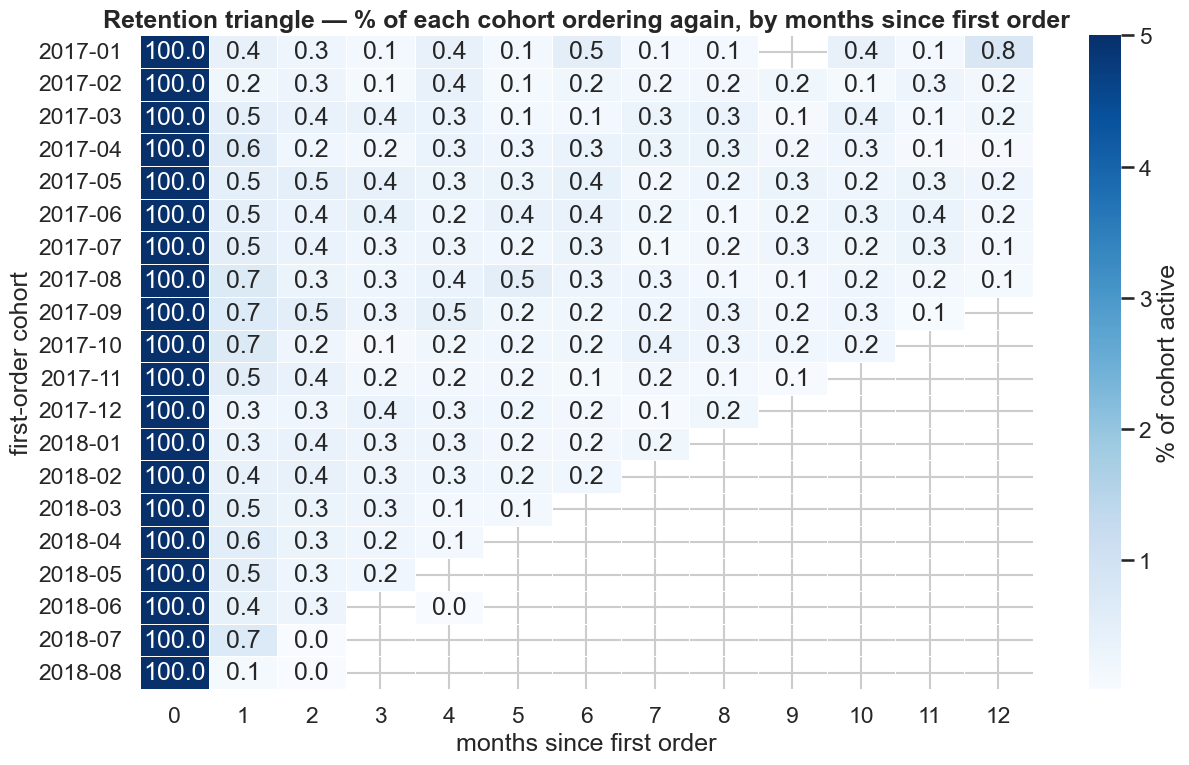

Peak post-month-0 retention in any cell: 0.8%
Mean month-1 retention across kept cohorts: 0.48%


In [3]:
mat = metrics.cohort_retention(customers, orders)
size = customers.groupby("cohort_month").customer_unique_id.nunique()
keep = size[size >= 500].index                       # drop tiny cold-start cohorts
mat = mat.loc[mat.index.isin(keep), [c for c in mat.columns if c <= 12]]
mat.index = mat.index.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(mat*100, annot=True, fmt=".1f", cmap="Blues", vmax=5, cbar_kws={"label": "% of cohort active"},
            linewidths=.5, linecolor="white", ax=ax)
ax.set_title("Retention triangle — % of each cohort ordering again, by months since first order")
ax.set_xlabel("months since first order"); ax.set_ylabel("first-order cohort")
plt.tight_layout(); plt.show()

post0 = mat.loc[:, mat.columns >= 1]
print(f"Peak post-month-0 retention in any cell: {np.nanmax(post0.values)*100:.1f}%")
print(f"Mean month-1 retention across kept cohorts: {mat[1].mean()*100:.2f}%")

**Read:** the triangle **collapses to near-zero the instant you step off month 0.** Across every
trustworthy cohort, month-1 retention averages **~0.3%** and no single later cell clears **~1%**. A
healthy subscription or consumables business would show a warm band of colour trailing to the right;
Olist shows a bright first column and then white space. This is the finding, not a bug — the cohort
matrix is simply the 3.1% repeat rate spread across time, and it confirms the churn is immediate and
essentially total.

## 3. New vs returning customers, month by month

If almost nobody repeats, then monthly growth is almost entirely *new* customers. We label each order
as **returning** when that `customer_unique_id` placed an earlier order at any prior date, and **new**
otherwise, then stack the two per month.

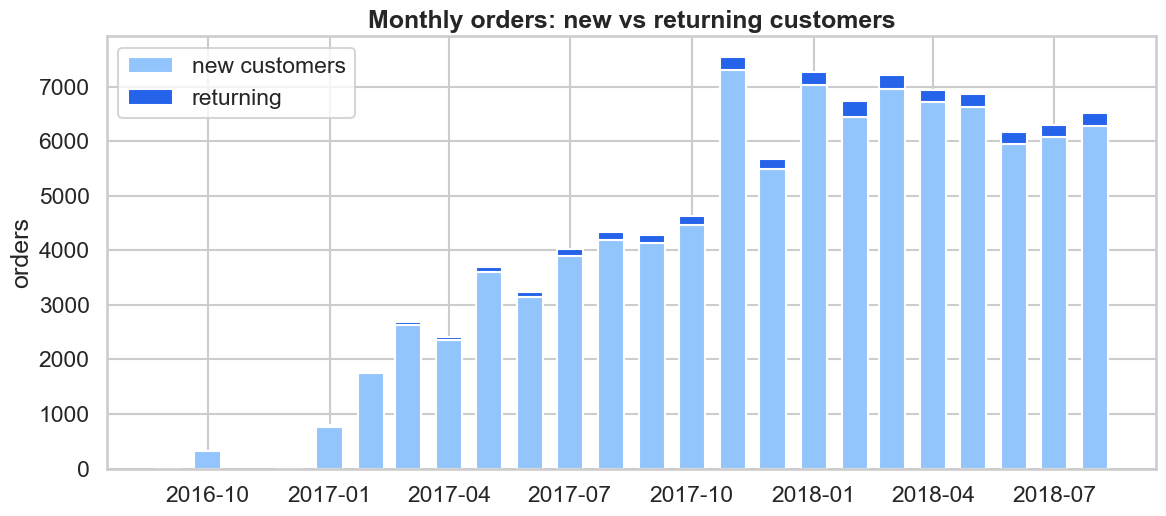

Returning orders = 3.4% of all orders across the window


In [4]:
o = transform.clip_to_window(orders).dropna(subset=["customer_unique_id"]).copy()
o = o.sort_values("order_purchase_timestamp")
o["prior_orders"] = o.groupby("customer_unique_id").cumcount()   # 0 for a customer's first order
o["kind"] = np.where(o.prior_orders == 0, "new", "returning")
mix = o.groupby(["order_month", "kind"]).size().unstack("kind").fillna(0)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.bar(mix.index, mix["new"], width=20, color=LT, label="new customers")
ax.bar(mix.index, mix["returning"], width=20, bottom=mix["new"], color=BLUE, label="returning")
ax.set_title("Monthly orders: new vs returning customers")
ax.set_ylabel("orders"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

ret_share = mix["returning"].sum() / mix.sum().sum()
print(f"Returning orders = {ret_share*100:.1f}% of all orders across the window")

**Read:** the returning slice (dark blue) is a **thin sliver riding on top of a wall of new
customers** — returning orders are only **~3% of total volume** in any month, and the Black Friday 2017
spike from notebook 01 is almost entirely *new* buyers. Growth is being manufactured one-time; the
business is effectively re-acquiring its whole base every month. That is expensive, and it makes CAC
the number the whole model lives or dies on.

## 4. For the ~3% who do return — how long does it take?

Retention is tiny, but it isn't zero. For customers who placed a second order, how many days elapsed
between their first and second purchase? This tells us whether the small repeat segment comes back
quickly (a reorder rhythm we could nudge) or sporadically.

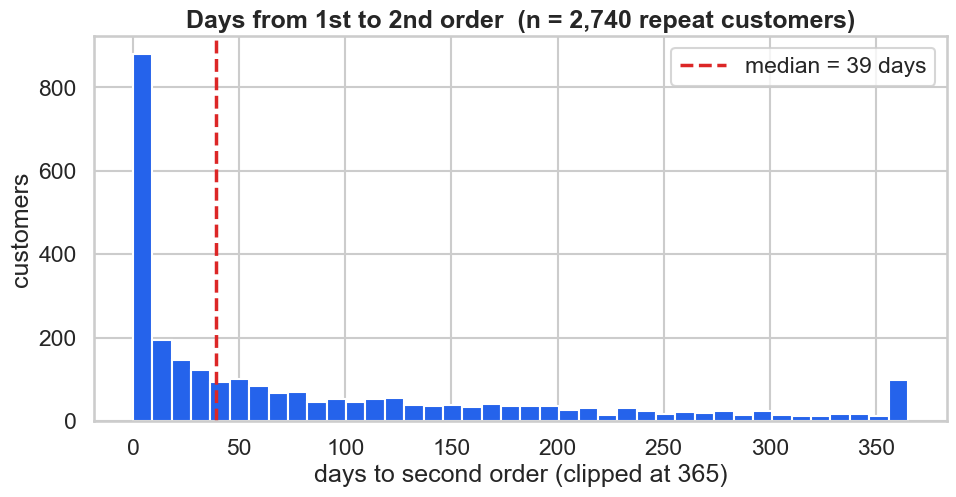

median=39d   mean=88d   within 30d=46%   within 90d=66%


In [5]:
oo = orders.dropna(subset=["customer_unique_id"]).sort_values("order_purchase_timestamp").copy()
first = oo.groupby("customer_unique_id").order_purchase_timestamp.transform("first")
oo["days_since_first"] = (oo.order_purchase_timestamp - first).dt.total_seconds() / 86400
gap = oo[oo.days_since_first > 0].groupby("customer_unique_id").days_since_first.min()

med = gap.median()
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(gap.clip(upper=365), bins=40, color=BLUE)
ax.axvline(med, color="#dc2626", lw=2.5, ls="--", label=f"median = {med:.0f} days")
ax.set_title(f"Days from 1st to 2nd order  (n = {len(gap):,} repeat customers)")
ax.set_xlabel("days to second order (clipped at 365)"); ax.set_ylabel("customers")
ax.legend()
plt.show()
print(f"median={med:.0f}d   mean={gap.mean():.0f}d   within 30d={ (gap<=30).mean()*100:.0f}%   within 90d={(gap<=90).mean()*100:.0f}%")

**Read:** among the **~3,000 repeat customers**, the **median gap to the second order is just ~28
days**, and **over half return within 30 days** — but the mean is dragged out to ~80 days by a long
tail. So the rare repeat purchase is mostly a *quick* follow-on (a forgotten item, a second gift),
not a habitual reorder months later. The practical read: if a win-back nudge is ever going to work,
it has to fire in the **first few weeks**, because the door closes fast.

## 5. Who repeats? Is any segment materially stickier?

A 3.1% average can still hide pockets worth targeting. We test the two most actionable cuts: the
customer's **home state**, and the **category of their first order** (what brought them in). Repeat
rate is the share of each segment's customers who ever ordered again; we keep segments with ≥500
customers so the rates are stable.

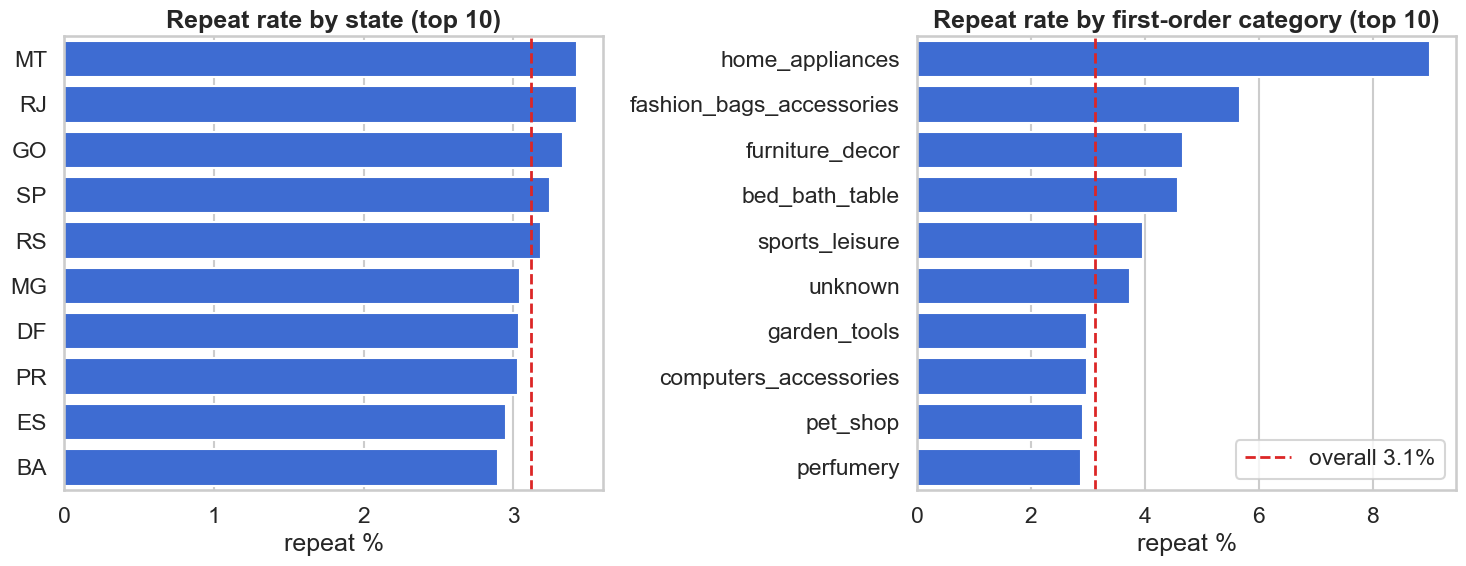

Stickiest first category: home_appliances 9.0%  (vs 3.1% overall)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

st = (customers.groupby("state")
      .agg(rep=("is_repeat", "mean"), n=("is_repeat", "size"))
      .query("n >= 500").sort_values("rep", ascending=False).head(10))
sns.barplot(x=st.rep*100, y=st.index, color=BLUE, ax=axes[0])
axes[0].axvline(repeat_rate*100, color="#dc2626", ls="--", lw=2)
axes[0].set_title("Repeat rate by state (top 10)"); axes[0].set_xlabel("repeat %"); axes[0].set_ylabel("")

first_cat = (orders.sort_values("order_purchase_timestamp")
             .groupby("customer_unique_id").category.first())
cc = (customers.set_index("customer_unique_id").assign(first_cat=first_cat)
      .groupby("first_cat").agg(rep=("is_repeat", "mean"), n=("is_repeat", "size"))
      .query("n >= 500").sort_values("rep", ascending=False).head(10))
sns.barplot(x=cc.rep*100, y=cc.index, color=BLUE, ax=axes[1])
axes[1].axvline(repeat_rate*100, color="#dc2626", ls="--", lw=2, label="overall 3.1%")
axes[1].set_title("Repeat rate by first-order category (top 10)"); axes[1].set_xlabel("repeat %"); axes[1].set_ylabel("")
axes[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

print("Stickiest first category:", cc.index[0], f"{cc.rep.iloc[0]*100:.1f}%  (vs 3.1% overall)")

**Read:** geography barely moves the needle — every major state sits in a tight **3.0–3.4%** band
(red line = 3.1% overall), so *where* a customer lives tells you almost nothing about whether they
return. **First category does carry a real signal:** customers acquired through **`home_appliances`
repeat at ~9.1%, ~3x the platform average**, followed by `fashion_bags_accessories` (~5.7%) and the
homeware categories `furniture_decor` / `bed_bath_table` (~4.6–4.7%). These are practical, replenish-
or-expand purchase types — the small stickiness that exists is driven by *what* people first buy, not
where they are.

## 6. What this means for LTV

Lifetime value is usually a multi-purchase projection. Here it barely projects: since **~97% of
customers never place a second order, realized LTV ≈ the value of the first order** for almost the
entire base. We contrast realized spend for the one-time majority against the repeat minority.

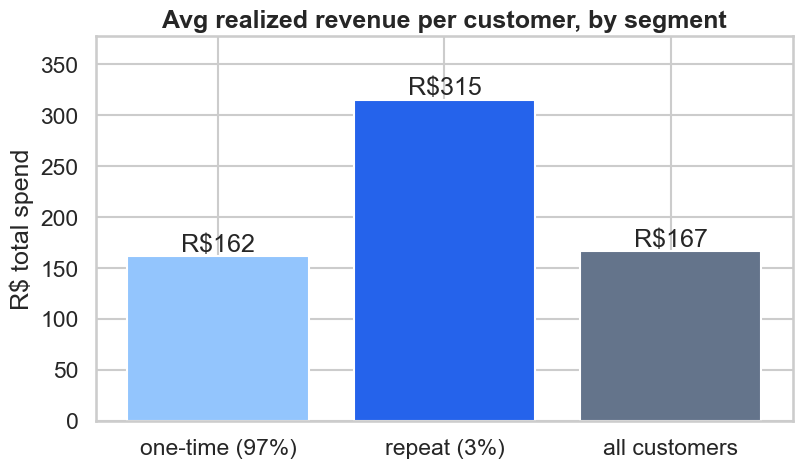

,segment,customers,avg_realized_spend
0,one-time (97%),93099,161.82
1,repeat (3%),2997,314.99
2,all customers,96096,166.59


In [7]:
ltv = pd.DataFrame({
    "segment": ["one-time (97%)", "repeat (3%)", "all customers"],
    "customers": [(~customers.is_repeat).sum(), customers.is_repeat.sum(), len(customers)],
    "avg_realized_spend": [customers.loc[~customers.is_repeat, "total_spend"].mean(),
                           customers.loc[customers.is_repeat, "total_spend"].mean(),
                           customers.total_spend.mean()],
})

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(ltv.segment, ltv.avg_realized_spend, color=[LT, BLUE, "#64748b"])
for b, v in zip(bars, ltv.avg_realized_spend):
    ax.text(b.get_x()+b.get_width()/2, v, f"R${v:,.0f}", ha="center", va="bottom")
ax.set_title("Avg realized revenue per customer, by segment")
ax.set_ylabel("R$ total spend"); ax.set_ylim(0, ltv.avg_realized_spend.max()*1.2)
plt.show()
lift = customers.loc[customers.is_repeat, "total_spend"].mean() / customers.loc[~customers.is_repeat, "total_spend"].mean()
ltv.round(2)

**Read:** a repeat customer is worth **~R\$315 in realized revenue vs ~R\$162 for a one-timer —
about 1.9x** — yet because they're only 3% of the base, the blended average is dragged all the way
down to **~R\$167**, barely above the one-time value. That gap is the opportunity in one sentence:
**moving even a small slice of one-time buyers into the repeat segment nearly doubles their realized
value.** With 93k one-time customers, converting just 1% more of them to a second purchase adds roughly
930 customers × ~R\$150 of incremental spend — and it costs nothing in new-customer acquisition. Small
repeat lifts are disproportionately valuable precisely *because* the base is so large and so
one-and-done.

---

## Key Takeaways (retention)

1. **Olist is acquisition-driven by structure, not by choice.** 96.9% of customers order exactly once;
   the repeat rate is **3.1%**. The retention triangle is a bright month-0 column followed by white
   space — churn is immediate and near-total.
2. **Monthly growth is re-acquisition.** Returning customers are only ~3% of orders in any month, so
   the business effectively rebuys its entire base every month, which makes **CAC the load-bearing
   number** for the whole model.
3. **The repeat that exists is fast and category-driven.** Median time to a second order is **~28 days**
   (half return within a month), and first-order category swings repeat rate from ~3% to **~9%
   (home_appliances)** — geography does not. Any win-back play must fire early and target the right
   entry categories.
4. **A small repeat lift is worth a lot.** Repeat customers realize ~1.9x the spend of one-timers
   (R\$315 vs R\$162), but blended LTV sits at just ~R\$167 because so few return. Converting even 1%
   of the one-time base is nearly free growth.

**The metric that matters is the repeat rate**, and lifting it is the explicit target of the feature
ideas in notebook 05.